# LangGraph - First Node

> Building Simple Stateful Workflows

In the previous chapter, we built a simple ReAct agent using only `LangChain`. Now, we will begin building with `LangGraph`.

In this section, we will creat our first node and our first graph.

To introduce fundamental graph-based workflows in LangGraph, let’s start by constructing a simple stateful node.

Here, we’ll define an agent whose primary role is to greet the user, showcasing how to model a conversational flow with clear state management.

In [6]:
from typing import List, TypedDict
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    message: str

To manage and pass information through our LangGraph workflow, we need a way to represent the current state of the conversation or agent. That’s where the `AgentState` comes in.

A **node** represents a step or action in our workflow — think of it as a function that does some work and moves the state forward. Each node function takes the current state as input, possibly modifies it, and then returns the new (or updated) state.

In [7]:
def greeting_node(state: AgentState) -> AgentState:
    """Simple node that modifies the state to include a greeting message."""
    state["message"] = "Hello! " + state.get("message", "") + " How can I assist you today?"
    return state

The function receives the `state` dictionary, which is expected to have a `"message"` key (since it matches the `AgentState` structure).

The updated state dictionary is returned, now containing the new greeting message.

We create a `StateGraph` object and tell it what kind of state it’ll be working with — here, our previously defined `AgentState`.

In [8]:
graph = StateGraph(AgentState)

graph.add_node("greeting", greeting_node)

graph.set_entry_point("greeting")
graph.set_finish_point("greeting")

app = graph.compile()

We add a node named `"greeting"` to the graph, and tells LangGraph to use the `greeting_node` function whenever the graph execution reaches this node.

* **Entry Point**: Start the workflow at the `"greeting"` node.

* **Finish Point**: Consider the workflow complete after running the `"greeting"` node.

By establishing this node as both the start and end point, the graph represents a direct and self-contained interaction: the agent receives the state, adds a greeting, and finishes.

We compile the graph into an executable application.

We can render the graph as a diagram.

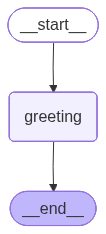

In [9]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

The rendered diagram visually affirms this flow, showing the process from start (`__start__`) through the greeting node, and finally to the end (`__end__`).

To run our graph and see it in action, we use the `invoke` method of the compiled app, passing in an initial state dictionary.

In [10]:
response = app.invoke({"message": "Laercio"})

print(response)

{'message': 'Hello! Laercio How can I assist you today?'}


---

It’s common to track more than one piece of information in our state. Here’s how to design a graph node that handles multiple attributes, such as a user’s name, a list of values, and a computed result.

In [11]:
class AgentState(TypedDict):
    values: List[int]
    name: str
    result: str

The `process_values` node takes the current state, calculates the sum of the `values` list, and creates a personalized message using the `name` attribute. This message is stored in `result` and returned as part of the updated state.

In [12]:
def process_values(state: AgentState) -> AgentState:
    """
    Processes the values in the state and calculates their sum.
    """
    state["result"] = f"Hi {state['name']}. The total of your values is {sum(state['values'])}."
    return state

In [13]:
graph = StateGraph(AgentState)

graph.add_node("processor", process_values)
graph.set_entry_point("processor")
graph.set_finish_point("processor")

app = graph.compile()

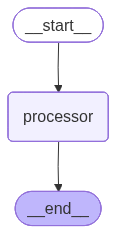

In [14]:
display(Image(app.get_graph().draw_mermaid_png()))

When we invoke this workflow:

In [15]:
response = app.invoke({"values": [1, 2, 3], "name": "Laercio"})

print(response)

{'values': [1, 2, 3], 'name': 'Laercio', 'result': 'Hi Laercio. The total of your values is 6.'}


With these simple examples, you’ve seen how to build, run, and visualize stateful workflows in LangGraph — from a single greeting node to processing multiple attributes.